alpha*t = 0.7153919999999999
beta = 2*sqrt(alpha*t) = 1.691616977923785
f(0)    = -15.0
f(xbar) = 12.655775370958484


/var/folders/gq/h1h8jf9s2ljgh3cq6yfxgcbm0000gn/T/ipykernel_16887/3170026755.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


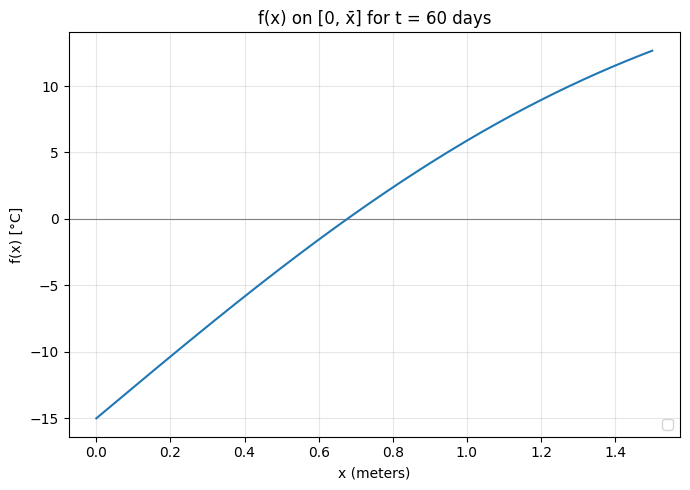

In [6]:
#Problem 2a
import numpy as np
from scipy.special import erf
import matplotlib.pyplot as plt

#params 
Ti = 20.0           
Ts = -15.0           
alpha = 0.138e-6    
t = 60 * 86400       

#beta = 2*sqrt(alpha*t)
beta = 2 * np.sqrt(alpha * t)
print("alpha*t =", alpha * t)
print("beta = 2*sqrt(alpha*t) =", beta)

def f(x):
    """root-finding function: f(x) = 0 when soil at depth x just reaches freezing"""
    return Ts + (Ti - Ts) * erf(x / beta)

def fprime(x):
    """derivative of f with respect to x"""
    return (Ti - Ts) * (2 / np.sqrt(np.pi)) * np.exp(-(x / beta) ** 2) / beta

#xbar must satisfy f(xbar) > 0
xbar = 1.5
x_plot = np.linspace(0, xbar, 500)
y_plot = f(x_plot)

print("f(0)    =", f(0.0))
print("f(xbar) =", f(xbar))

plt.figure(figsize=(7, 5))
plt.axhline(0, color='gray', linewidth=0.8)
plt.plot(x_plot, y_plot)
plt.xlabel('x (meters)')
plt.ylabel('f(x) [°C]')
plt.title('f(x) on [0, x̄] for t = 60 days')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('f_plot.png', dpi=150)
plt.show()

In [8]:
#Problem 2b

#params are defined in part a

def f(x):
    """root-finding function: f(x) = 0 when soil at depth x just reaches freezing."""
    return Ts + (Ti - Ts) * erf(x / beta)


def bisection(f, a, b, tol=1e-13, max_iter=200):
    """
    bisection method for finding a root of f on [a, b]

    parameters
    ----------
    f        : function handle
    a, b     : initial interval endpoints, must satisfy f(a)*f(b) < 0
    tol      : stopping tolerance on the interval half-width |b - a| / 2
    max_iter : cap on iterations

    returns
    -------
    p        : approximate root
    n        : number of iterations performed
    """
    fa = f(a)
    fb = f(b)
    if fa * fb > 0:
        raise ValueError("f(a) and f(b) must have opposite signs")

    for n in range(1, max_iter + 1):
        p = 0.5 * (a + b)
        fp = f(p)

        #stop once the interval is small enough (or we hit the root exactly)
        if fp == 0.0 or (b - a) / 2 < tol:
            return p, n

        if fa * fp < 0:
            b = p
            fb = fp
        else:
            a = p
            fa = fp

    return p, n


#initial interval as specified: a0 = 0, b0 = xbar
a0 = 0.0
b0 = 1.5   #xbar from part (a), where f(xbar) > 0
tol = 1e-13

root, num_iters = bisection(f, a0, b0, tol=tol)

print(f"Number of iterations: {num_iters}")
print(f"Approximate root (burial depth): x = {root:.12f} meters")
print(f"f(x) at root = {f(root):.3e}")

Number of iterations: 44
Approximate root (burial depth): x = 0.676961854482 meters
f(x) at root = -6.750e-13


In [9]:
#Problem 2c

#params & f and f' are defined in part a

def newton(f, fprime, x0, tol=1e-13, max_iter=200):
    """
    newton's method for finding a root of f, starting from x0

    returns
    -------
    x     : approximate root
    n     : number of iterations performed
    """
    x = x0
    for n in range(1, max_iter + 1):
        x_new = x - f(x) / fprime(x)
        if abs(x_new - x) < tol:
            return x_new, n
        x = x_new
    return x, n


tol = 1e-13
xbar = 1.5  

#starting value x0 = 0.01
root_a, iters_a = newton(f, fprime, 0.01, tol=tol)
print("Starting at x0 = 0.01:")
print(f"  Number of iterations: {iters_a}")
print(f"  Approximate root (burial depth): x = {root_a:.12f} meters")
print(f"  f(x) at root = {f(root_a):.3e}")

#starting value x0 = xbar
root_b, iters_b = newton(f, fprime, xbar, tol=tol)
print("\nStarting at x0 = xbar =", xbar, ":")
print(f"  Number of iterations: {iters_b}")
print(f"  Approximate root (burial depth): x = {root_b:.12f} meters")
print(f"  f(x) at root = {f(root_b):.3e}")

Starting at x0 = 0.01:
  Number of iterations: 5
  Approximate root (burial depth): x = 0.676961854482 meters
  f(x) at root = 0.000e+00

Starting at x0 = xbar = 1.5 :
  Number of iterations: 6
  Approximate root (burial depth): x = 0.676961854482 meters
  f(x) at root = 0.000e+00


In [10]:
#Problem 3

#fixed pt functions
def g_a(x):
    return x * (1 + (7 - x**5) / x**2)**3

def g_b(x):
    return x - (x**5 - 7) / x**2

def g_c(x):
    return x - (x**5 - 7) / (5 * x**4)

def g_d(x):
    return x - (x**5 - 7) / 12

p = 7 ** (1/5) 


def fixed_point_iteration(g, x0, tol=1e-10, max_iter=200):
    """
    fixed-point iteration: x_{n+1} = g(x_n)

    stops when |x_{n+1} - x_n| < tol, or flags divergence if the
    iterate blows up

    returns
    -------
    x         : final iterate (approx. root if converged)
    n         : number of iterations performed
    converged : bool
    """
    x = x0
    for n in range(1, max_iter + 1):
        x_new = g(x)

        if not np.isfinite(x_new) or abs(x_new) > 1e12:
            return x_new, n, False   #diverged

        if abs(x_new - x) < tol:
            return x_new, n, True    #converged

        x = x_new

    return x, max_iter, False        #did not converge within max_iter


tol = 1e-10
x0 = 1.0

print(f"True root p = 7^(1/5) = {p:.12f}\n")

for g, name in [(g_a, "(a)"), (g_b, "(b)"), (g_c, "(c)"), (g_d, "(d)")]:
    root, n, converged = fixed_point_iteration(g, x0, tol=tol, max_iter=200)
    status = "CONVERGED" if converged else "did NOT converge (within 200 iterations)"
    print(f"{name}: {status}")
    print(f"    iterations = {n}, last value = {root}")
    print()

True root p = 7^(1/5) = 1.475773161595

(a): did NOT converge (within 200 iterations)
    iterations = 2, last value = -2.2539338614955004e+25

(b): did NOT converge (within 200 iterations)
    iterations = 4, last value = -5.437255629158596e+22

(c): CONVERGED
    iterations = 8, last value = 1.475773161594552

(d): did NOT converge (within 200 iterations)
    iterations = 200, last value = 1.4755730674756178

